In [1]:
print("hello world")

hello world


In [2]:
# Import libraries
import pandas as pd
from sklearn.datasets import fetch_openml

In [4]:
titanic = fetch_openml(name="titanic",version=1, as_frame=True)
data = pd.DataFrame(titanic.data)

data.head()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\datasets\_arff_parser.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frame = pd.concat(dfs, ignore_index=True)


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"


 1. Check for missing values and handle them.
 2. Check for duplicate rows and remove them.
 3. Inspect the "Sex" column for inconsistencies and standardize values.
 4. Detect and handle outliers in the "Age" and "Fare" columns.
 5. Create a new "Family_Size" feature based on "SibSp" and "Parch".
 6. Convert the "Embarked" column to numerical values using label encoding.
 7. If a "Ticket_Purchase_Date" column existed, convert it to datetime and extract the year and onth.
 8. Clean the "Name" column by removing titles and converting to lowercase.
 9. Bin the "Age" column into categories like 'Child', 'Teen', 'Adult', and 'Senior'.

In [9]:
#Q1
data.isnull().sum()

# Filling na values as UNKNOWN
data["cabin"].fillna("UNKNOWN", inplace=True)

# Dropping values ONLY for one col
data.dropna(subset=["embarked"], inplace=True)

data.isnull().sum()

pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin           0
embarked        0
boat          823
body         1186
home.dest     563
dtype: int64

In [ ]:
#Q2
data.duplicated().sum()

0

In [15]:
#Q3
data.sex.value_counts()

sex
male      843
female    464
Name: count, dtype: int64

In [ ]:
#Q4 
data[['age','fare']]

# Filling the age and fare NA values with averages 
data["age"].fillna(data["age"].mean(), inplace=True)
data["fare"].dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1307 non-null   float64 
 1   name       1307 non-null   object  
 2   sex        1307 non-null   category
 3   age        1307 non-null   float64 
 4   sibsp      1307 non-null   float64 
 5   parch      1307 non-null   float64 
 6   ticket     1307 non-null   object  
 7   fare       1306 non-null   float64 
 8   cabin      1307 non-null   object  
 9   embarked   1307 non-null   category
 10  boat       484 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  744 non-null    object  
dtypes: category(2), float64(6), object(5)
memory usage: 125.3+ KB


,pclass,age,sibsp,parch,fare,body
count,1307.000000,1307.000000,1307.000000,1307.000000,1306.000000,121.000000
mean,2.296863,29.842593,0.499617,0.385616,33.223956,160.809917
std,0.836942,12.860382,1.042273,0.866092,51.765986,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,29.842593,0.000000,0.000000,14.454200,155.000000
75%,3.000000,35.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


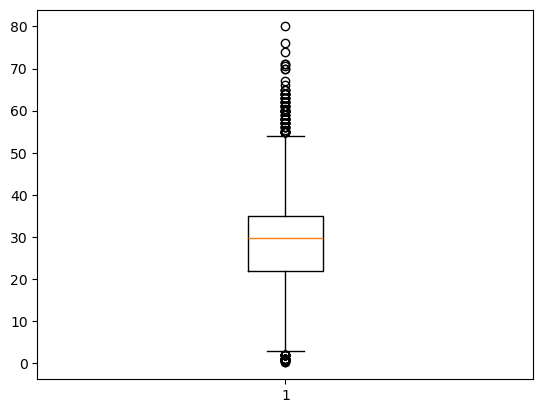

In [24]:
import matplotlib.pyplot as plt

plt.boxplot(data.age)
plt.show()

In [29]:
# working out the outliers

def outlierCheck(df, colName):
    q1 = df[colName].quantile(0.25)
    q3 = df[colName].quantile(0.75)

    IQR = q3-q1

    #Filtering the outliers
    outlierDF = df.loc[(df[colName] < (q1-1.5*IQR)) | (df[colName] > (q3 + 1.5*IQR))]

    return outlierDF

In [30]:
outliers = outlierCheck(df=data, colName = 'age')
outliers.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"
6,1.0,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1.0,0.0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
9,1.0,"Artagaveytia, Mr. Ramon",male,71.0000,0.0,0.0,PC 17609,49.5042,UNKNOWN,C,None,22.0,"Montevideo, Uruguay"
14,1.0,"Barkworth, Mr. Algernon Henry Wilson",male,80.0000,0.0,0.0,27042,30.0000,A23,S,B,NaN,"Hessle, Yorks"


In [31]:
# Q5

data["famSize"] = data["sibsp"] + data["parch"] + 1
data.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,famSize
0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1.0
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",4.0
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0
3,1.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON",4.0
4,1.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0


In [33]:
# Q6 

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

data["embarked_encoded"] = label_encoder.fit_transform(data["embarked"]) 
data.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,famSize,embarked_encoded
0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1.0,2
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",4.0,2
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0,2
3,1.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON",4.0,2
4,1.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0,2


In [40]:
# Q8 
data["name_V2"] = data["name"].str.replace(
    r'\s*(Mr|Mrs|Miss|Ms|Dr)\.?\s+',
    '',
    regex=True
)
data.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,famSize,embarked_encoded,name_V2
0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1.0,2,"Allen,Elisabeth Walton"
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison, Master. Hudson Trevor"
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison,Helen Loraine"
3,1.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison,Hudson Joshua Creighton"
4,1.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison,Hudson J C (Bessie Waldo Daniels)"


In [39]:
data.iloc[0]["name"]

'Allen, Miss. Elisabeth Walton'

In [42]:
# Q9
bins = [0,12,18,64,150]
labels = ["child", "teen", "adult", "senior"]

data["age_group"] = pd.cut(data["age"],bins=bins, labels=labels)
data.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,famSize,embarked_encoded,name_V2,age_group
0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1.0,2,"Allen,Elisabeth Walton",adult
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison, Master. Hudson Trevor",child
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison,Helen Loraine",child
3,1.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison,Hudson Joshua Creighton",adult
4,1.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",4.0,2,"Allison,Hudson J C (Bessie Waldo Daniels)",adult
